# **Prediksi Potensi Produksi Padi di Indonesia Berdasarkan Kondisi Iklim Menggunakan Machine Learning**
----

SDGs Target: SDG 13 — Climate Action | SDG 2 — Zero Hunger.

Tim: JUJUR GW LUPA NAMANYA APA TP ITU POKOKNYA.

## 00. Dataset

In [2]:
!pip install kaggle

import os
os.makedirs('data/raw', exist_ok=True)

!kaggle datasets download -d greegtitan/indonesia-climate -p data/raw --unzip
!kaggle datasets download -d nurfianqodar/indonesian-rice-production-dataset -p data/raw --unzip

print("don")

^C
Dataset URL: https://www.kaggle.com/datasets/greegtitan/indonesia-climate
License(s): copyright-authors




  0%|          | 0.00/7.15M [00:00<?, ?B/s]
 14%|█▍        | 1.00M/7.15M [00:00<00:05, 1.13MB/s]
 28%|██▊       | 2.00M/7.15M [00:01<00:04, 1.30MB/s]
 42%|████▏     | 3.00M/7.15M [00:02<00:03, 1.30MB/s]
 56%|█████▌    | 4.00M/7.15M [00:03<00:02, 1.40MB/s]
 70%|██████▉   | 5.00M/7.15M [00:03<00:01, 1.67MB/s]
 84%|████████▍ | 6.00M/7.15M [00:03<00:00, 1.99MB/s]
 98%|█████████▊| 7.00M/7.15M [00:04<00:00, 2.04MB/s]
100%|██████████| 7.15M/7.15M [00:04<00:00, 1.66MB/s]


Dataset URL: https://www.kaggle.com/datasets/nurfianqodar/indonesian-rice-production-dataset
License(s): apache-2.0

don



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 3.38MB/s]


# 01. Data Collection & Exploration

In [ ]:
!pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl (12.5 MB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-n

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
file_padi = '../data/raw/idrice.csv'
file_iklim = '../data/raw/climate_data.csv'

df_rice = pd.read_csv(file_padi)
df_climate = pd.read_csv(file_iklim)

display(df_rice.head())
display(df_climate.head())

,province,production,productivity,harvest_area,year
0,Aceh,1861567100,5649,329515.78,2018
1,Sumatera Utara,2108284720,5165,408176.45,2018
2,Sumatera Barat,1483076480,4737,313050.82,2018
3,Riau,266375530,3728,71448.08,2018
4,Jambi,383045740,4444,86202.68,2018


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id
0,01-01-2010,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001
1,02-01-2010,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001
2,03-01-2010,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001
3,04-01-2010,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001
4,05-01-2010,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001


### Cek shape, dtypes, dan sample data

In [3]:
#check bentuk data
print("data padi:", df_rice.shape[0], "baris dan", df_rice.shape[1], "kolom.")
print("data iklim:", df_climate.shape[0], "baris dan", df_climate.shape[1], "kolom.")

data padi: 175 baris dan 5 kolom.
data iklim: 589265 baris dan 12 kolom.


In [4]:
#check data kosong
print("data kosong padi:")
print(df_rice.isnull().sum())
print("\ndata kosong iklim:")
print(df_climate.isnull().sum())

data kosong padi:
province        0
production      0
productivity    0
harvest_area    0
year            0
dtype: int64

data kosong iklim:
date               0
Tn             23383
Tx             37736
Tavg           45105
RH_avg         48182
RR            125384
ss             43721
ff_x           10214
ddd_x          13128
ff_avg         10127
ddd_car        13739
station_id         0
dtype: int64


In [5]:
#karena padi semuanya aman, tipe data iklim harus dicheck
df_climate.info()

<class 'pandas.DataFrame'>
RangeIndex: 589265 entries, 0 to 589264
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        589265 non-null  str    
 1   Tn          565882 non-null  float64
 2   Tx          551529 non-null  float64
 3   Tavg        544160 non-null  float64
 4   RH_avg      541083 non-null  float64
 5   RR          463881 non-null  float64
 6   ss          545544 non-null  float64
 7   ff_x        579051 non-null  float64
 8   ddd_x       576137 non-null  float64
 9   ff_avg      579138 non-null  float64
 10  ddd_car     575526 non-null  str    
 11  station_id  589265 non-null  int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 53.9 MB


### Identifikasi duplikat & Cek distribusi nilai per kolom

In [6]:
print("data padi yang duplikat:", df_rice.duplicated().sum())
print("data iklim yang duplikat:", df_climate.duplicated().sum())

data padi yang duplikat: 0
data iklim yang duplikat: 0


In [7]:
display(df_rice.describe())
display(df_climate.describe())

,production,productivity,harvest_area,year
count,1.750000e+02,175.000000,1.750000e+02,175.000000
mean,3.172778e+09,4528.480000,6.123151e+05,2020.000000
std,9.393780e+09,873.900602,1.800893e+06,1.418272
min,5.069100e+05,2653.000000,1.794800e+02,2018.000000
25%,2.336388e+08,3913.000000,5.359704e+04,2019.000000
50%,5.334774e+08,4663.000000,1.258701e+05,2020.000000
75%,1.701110e+09,5156.000000,3.274245e+05,2021.000000
max,5.920053e+10,7276.000000,1.137793e+07,2022.000000


,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,station_id
count,565882.000000,551529.000000,544160.000000,541083.000000,463881.000000,545544.000000,579051.000000,576137.000000,579138.000000,589265.000000
mean,23.312111,31.528955,26.855475,82.489365,8.680760,5.083199,4.709601,188.488325,1.956680,96832.949230
std,2.280687,2.311659,1.939656,14.337669,17.928752,3.261586,2.612285,107.657452,1.803358,542.419161
min,0.000000,0.000000,0.000000,24.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,96001.000000
25%,23.000000,30.500000,26.200000,79.000000,0.000000,2.500000,3.000000,90.000000,1.000000,96293.000000
50%,24.000000,31.800000,27.200000,83.000000,1.000000,5.300000,4.000000,180.000000,2.000000,96797.000000
75%,25.000000,33.000000,28.000000,87.000000,9.300000,7.600000,6.000000,270.000000,3.000000,97240.000000
max,246.000000,334.000000,141.600000,7520.000000,1965.500000,705.000000,185.000000,931.000000,160.000000,97980.000000


**outlier data iklim**

| Data | Label | Data |
|---|---|---|
| Suhu Udara | Tn Tx (min) | 0.0C |
| Kelembapan | RH_avg (max) | 7520% |
| Curah Hujan | RR (min) | -1.0 |
| Durasi Sinar Matahari | ss (max) | 705 jam |

# 02. Data Preprocessing & Cleaning

In [8]:
print("jumlah data iklim sebelum cleaning:", df_climate.shape[0])

df_climate = df_climate[df_climate['Tx'] <= 50]
df_climate = df_climate[df_climate['Tn'] >= 0]
df_climate = df_climate[(df_climate['RH_avg'] >= 0) & (df_climate['RH_avg'] <= 100)]
df_climate = df_climate[df_climate['RR'] >= 0]

print("jumlah data iklim setelah cleaning:", df_climate.shape[0])

jumlah data iklim sebelum cleaning: 589265
jumlah data iklim setelah cleaning: 406444


data iklim belum ada belum ada province dan tahun karena hanya punya date dan station

In [9]:
df_station = pd.read_csv('data/raw/station_detail.csv')
df_province = pd.read_csv('data/raw/province_detail.csv')

display(df_station.head())
display(df_province.head())

,station_id,station_name,region_name,latitude,longitude,region_id,province_id
0,96001,Stasiun Meteorologi Maimun Saleh,Kota Sabang,5.87655,95.33785,20,1
1,96003,Balai Besar Meteorologi Klimatologi dan Geofi...,Kab. Badung,-8.73810,115.17860,272,17
2,96004,Balai Besar Meteorologi Klimatologi dan Geofis...,Kota Makassar,-5.14283,119.45227,412,26
3,96009,Stasiun Meteorologi Malikussaleh,Kab. Aceh Utara,5.22869,96.94749,8,1
4,96011,Stasiun Meteorologi Sultan Iskandar Muda,Kab. Aceh Besar,5.52244,95.41700,6,1


,province_id,province_name
0,1,Nanggroe Aceh Darussalam
1,2,Sumatera Utara
2,3,Sumatera Barat
3,4,Riau
4,5,Jambi


combine (iklim + station) + province. 
extract year

In [10]:
df_climate_st = pd.merge(df_climate, df_station, on='station_id', how='inner')
df_climate_full = pd.merge(df_climate_st, df_province, on='province_id', how='inner')
df_climate_full['year'] = pd.to_datetime(df_climate_full['date'], format='mixed', dayfirst=True).dt.year
df_climate_full.rename(columns={'province_name': 'province'}, inplace=True)

#data baru untuk iklim
kolom_penting = ['date', 'year', 'province', 'Tn', 'Tx', 'Tavg', 'RH_avg', 'RR']
display(df_climate_full[kolom_penting].head())

,date,year,province,Tn,Tx,Tavg,RH_avg,RR
0,01-01-2010,2010,Nanggroe Aceh Darussalam,21.4,30.2,27.1,82.0,9.0
1,02-01-2010,2010,Nanggroe Aceh Darussalam,21.0,29.6,25.7,95.0,24.0
2,03-01-2010,2010,Nanggroe Aceh Darussalam,20.2,26.8,24.5,98.0,63.0
3,04-01-2010,2010,Nanggroe Aceh Darussalam,21.0,29.2,25.8,90.0,0.0
4,05-01-2010,2010,Nanggroe Aceh Darussalam,21.2,30.0,26.7,90.0,2.0


In [11]:
#karena ini masih perhari jadi harus diganti jadi pertahun dulu
df_climate_full['province'] = df_climate_full['province'].str.lower().str.strip()
df_rice['province'] = df_rice['province'].str.lower().str.strip()

climate_yearly = df_climate_full.groupby(['province', 'year']).agg({
    'Tavg': 'mean',     #rata-rata suhu
    'RH_avg': 'mean',   #rata-rata kelembapan
    'RR': 'sum'         #total curah hujan
}).reset_index()

climate_yearly.rename(columns={
    'Tavg': 'avg_temperature',
    'RH_avg': 'avg_humidity',
    'RR': 'total_rainfall'
}, inplace=True)

display(climate_yearly.head())

,province,year,avg_temperature,avg_humidity,total_rainfall
0,bali,2010,27.445708,82.726037,10617.6
1,bali,2011,26.661805,81.023827,7621.2
2,bali,2012,26.835754,81.302326,5589.1
3,bali,2013,27.578533,79.656530,3378.0
4,bali,2014,27.440179,78.614796,3806.0


In [12]:
df_merged = pd.merge(climate_yearly, df_rice, on=['province', 'year'], how='inner')
print("total baris:", df_merged.shape[0])
print("total kolom:", df_merged.shape[1])

display(df_merged.head())
print("check data kosong:", df_merged.isnull().sum())

total baris: 93
total kolom: 8


,province,year,avg_temperature,avg_humidity,total_rainfall,production,productivity,harvest_area
0,bali,2018,27.287625,79.916388,1236.7,667069060,6011,110978.37
1,bali,2019,27.310903,79.355140,954.8,579320530,6078,95319.34
2,bali,2020,27.774803,80.787402,1227.1,532168450,5849,90980.69
3,banten,2018,27.553233,80.399469,7127.3,1687783300,4894,344836.06
4,banten,2019,27.854355,78.435484,6447.7,1470503350,4842,303731.80


check data kosong: province           0
year               0
avg_temperature    0
avg_humidity       0
total_rainfall     0
production         0
productivity       0
harvest_area       0
dtype: int64


In [13]:
os.makedirs('data/processed', exist_ok=True)
df_merged.to_csv('data/processed/df_merged_clean.csv', index=False)

print("don")

don


### eda

In [14]:
df_awal = df_merged.copy()

plt.style.use('dark_background')
fig_color = '#0d0815'  
ax_color = '#1a1025'   
teks_color = '#e0d8f0' 

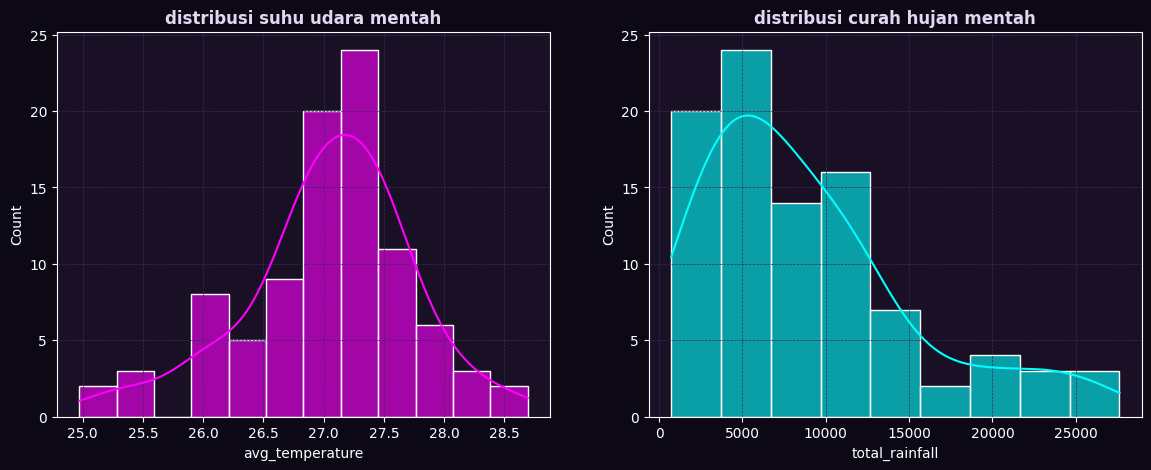

In [15]:
#distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(fig_color)

sns.histplot(df_awal['avg_temperature'], kde=True, color='#ff00ff', ax=axes[0], alpha=0.6)
axes[0].set_title('distribusi suhu udara mentah', color=teks_color, fontweight='bold')
axes[0].set_facecolor(ax_color)
axes[0].grid(color='#3b2a59', linestyle='--', linewidth=0.5)

sns.histplot(df_awal['total_rainfall'], kde=True, color='#00ffff', ax=axes[1], alpha=0.6)
axes[1].set_title('distribusi curah hujan mentah', color=teks_color, fontweight='bold')
axes[1].set_facecolor(ax_color)
axes[1].grid(color='#3b2a59', linestyle='--', linewidth=0.5)

plt.show()

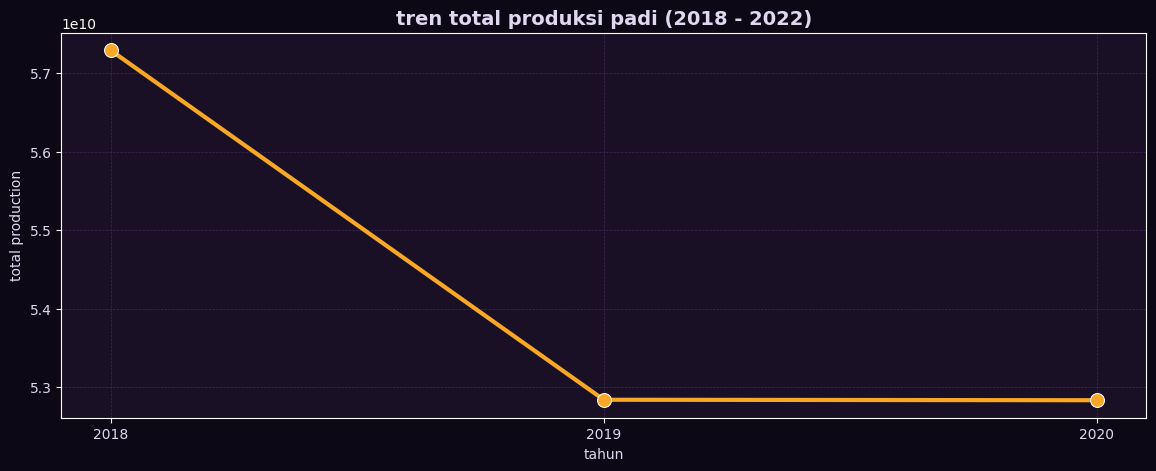

In [16]:
#time series
plt.figure(figsize=(14, 5))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

tren_nasional = df_awal.groupby('year')['production'].sum().reset_index()

sns.lineplot(data=tren_nasional, x='year', y='production', color='#f9a826', marker='o', linewidth=3, markersize=10)

plt.title('tren total produksi padi (2018 - 2022)', color=teks_color, fontsize=14, fontweight='bold')
plt.xlabel('tahun', color=teks_color)
plt.ylabel('total production', color=teks_color)
plt.xticks(tren_nasional['year'].unique(), color=teks_color)
plt.yticks(color=teks_color)
ax.grid(color='#3b2a59', linestyle='--', linewidth=0.5)
plt.show()

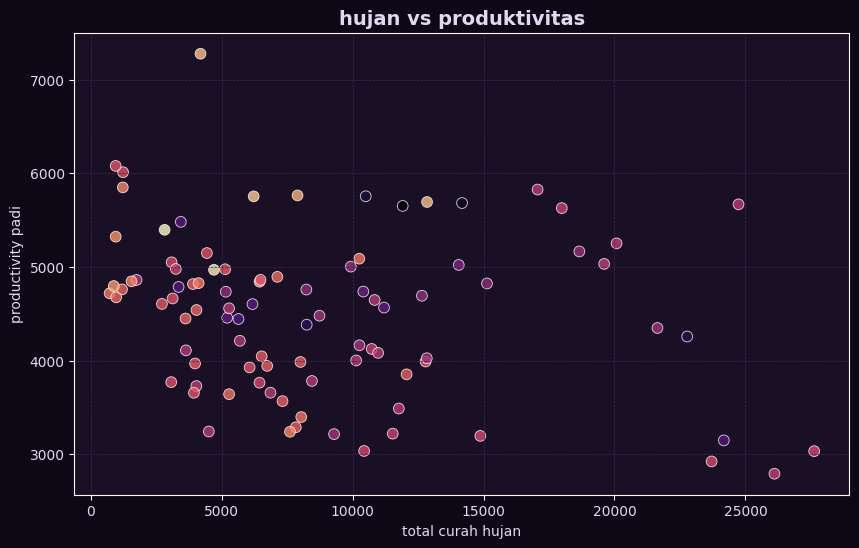

In [17]:
#scatter plot
plt.figure(figsize=(10, 6))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

sns.scatterplot(data=df_awal, x='total_rainfall', y='productivity', c=df_awal['avg_temperature'], cmap='magma', s=60, alpha=0.8)

plt.title('hujan vs produktivitas', color=teks_color, fontsize=14, fontweight='bold')
plt.xlabel('total curah hujan', color=teks_color)
plt.ylabel('productivity padi', color=teks_color)
plt.xticks(color=teks_color)
plt.yticks(color=teks_color)
ax.grid(color='#3b2a59', linestyle='--', linewidth=0.5)
plt.show()

# 03. Feature Engineering

In [18]:
df = df_merged.copy()

df['rainfall_category'] = pd.cut(df['total_rainfall'], bins=[0, 1000, 2000, np.inf], labels=['kering', 'normal', 'basah'])
df['temp_humidity_index'] = df['avg_temperature'] * df['avg_humidity']
df['rainfall_per_area'] = df['total_rainfall'] / (df['harvest_area'] + 1e-5)

#pemetaan region berdasarkan pulau
jawa = ['dki jakarta', 'jawa barat', 'jawa tengah', 'di yogyakarta', 'jawa timur', 'banten']
sumatera = ['nanggroe aceh darussalam', 'sumatera utara', 'sumatera barat', 'riau', 'jambi', 'sumatera selatan', 'bengkulu', 'lampung', 'kep. bangka belitung', 'kep. riau']
sulawesi = ['sulawesi utara', 'sulawesi tengah', 'sulawesi selatan', 'sulawesi tenggara', 'gorontalo', 'sulawesi barat']
kalimantan = ['kalimantan barat', 'kalimantan tengah', 'kalimantan selatan', 'kalimantan timur', 'kalimantan utara']
maluku_papua = ['maluku', 'maluku utara', 'papua barat', 'papua']

def get_region(prov):
    if prov in jawa: return 'Jawa'
    elif prov in sumatera: return 'Sumatera'
    elif prov in sulawesi: return 'Sulawesi'
    elif prov in kalimantan: return 'Kalimantan'
    elif prov in maluku_papua: return 'Maluku_Papua'
    else: return 'Bali_Nusa' # Bali, NTB, NTT


df['region'] = df['province'].apply(get_region)
df['is_java'] = df['region'].apply(lambda x: 1 if x == 'Jawa' else 0)

df_features = pd.get_dummies(df, columns=['rainfall_category', 'region'], drop_first=False)

kolom_baru = ['temp_humidity_index', 'rainfall_per_area', 'is_java']
display(df_features[kolom_baru].head())

,temp_humidity_index,rainfall_per_area,is_java
0,2180.728459,0.011144,0
1,2167.260570,0.010017,0
2,2243.854176,0.013487,0
3,2215.265286,0.020669,1
4,2184.769800,0.021228,1


In [19]:
os.makedirs('data/processed', exist_ok=True)
df_features.to_csv('data/processed/df_features.csv', index=False)

print("don")

don


### eda

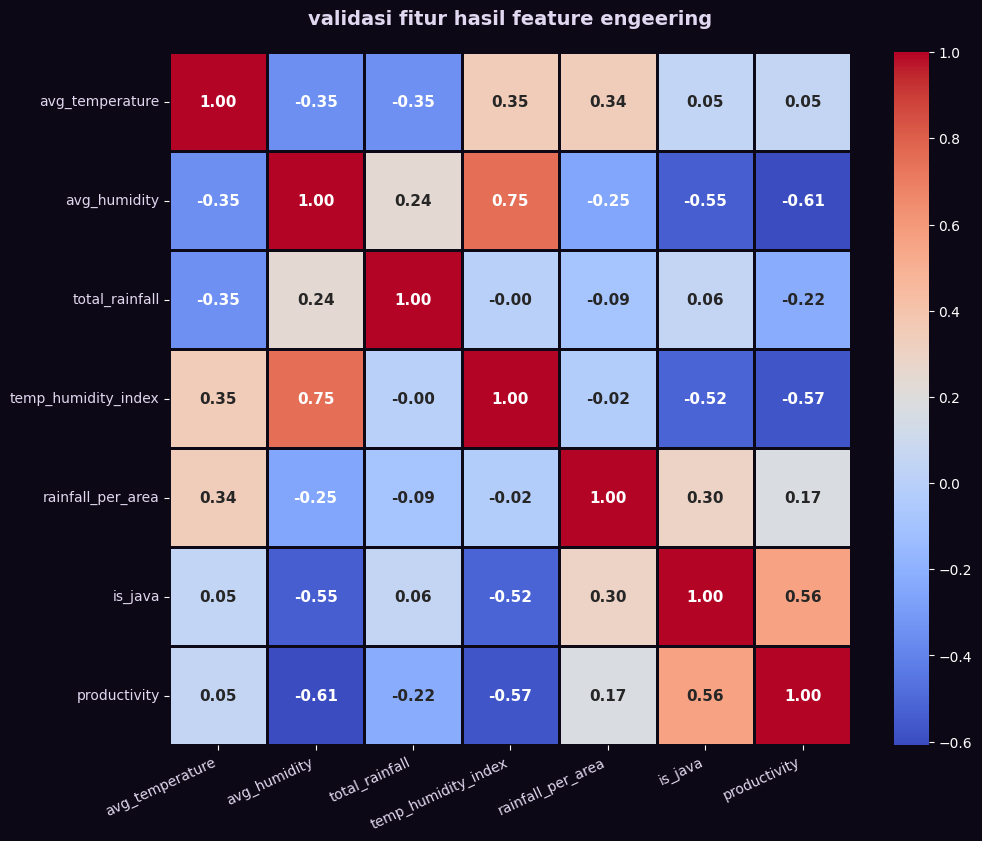

In [20]:
#heatmap
plt.figure(figsize=(11, 9))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

fitur_validasi = ['avg_temperature', 'avg_humidity', 'total_rainfall', 'temp_humidity_index', 'rainfall_per_area', 'is_java', 'productivity']

korelasi_baru = df_features[fitur_validasi].corr()

sns.heatmap(korelasi_baru, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, linecolor=fig_color, annot_kws={"size": 11, "weight": "bold"})

plt.title('validasi fitur hasil feature engeering', color=teks_color, fontsize=14, fontweight='bold', pad=20)
plt.xticks(color=teks_color, rotation=25, ha='right')
plt.yticks(color=teks_color)
plt.show()

berdasarkan heatmap yang bisa disimpulkan adalah
- avg_humidity dan temp_humidity_index berpengaruh secara negatif
- secara geografis berpengaruh cukup dominan (positif terbesar)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24848\350527961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='productivity', palette='magma', width=0.6)


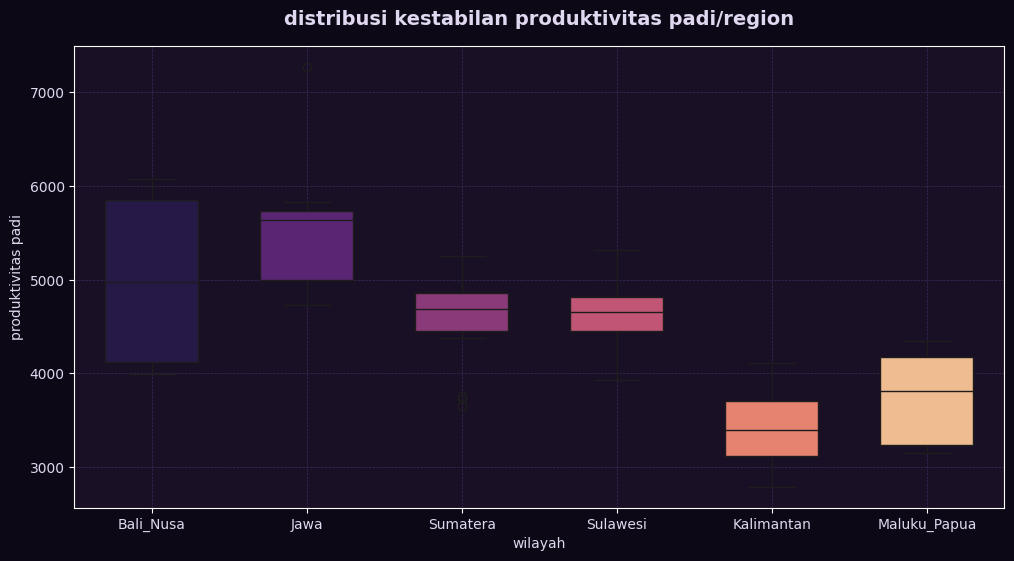

In [21]:
#box plot
plt.figure(figsize=(12, 6))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

sns.boxplot(data=df, x='region', y='productivity', palette='magma', width=0.6)

plt.title('distribusi kestabilan produktivitas padi/region', color=teks_color, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('wilayah', color=teks_color)
plt.ylabel('produktivitas padi', color=teks_color)
plt.xticks(color=teks_color)
plt.yticks(color=teks_color)
ax.grid(color='#3b2a59', linestyle='--', linewidth=0.5)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24848\466805154.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis', alpha=0.9)


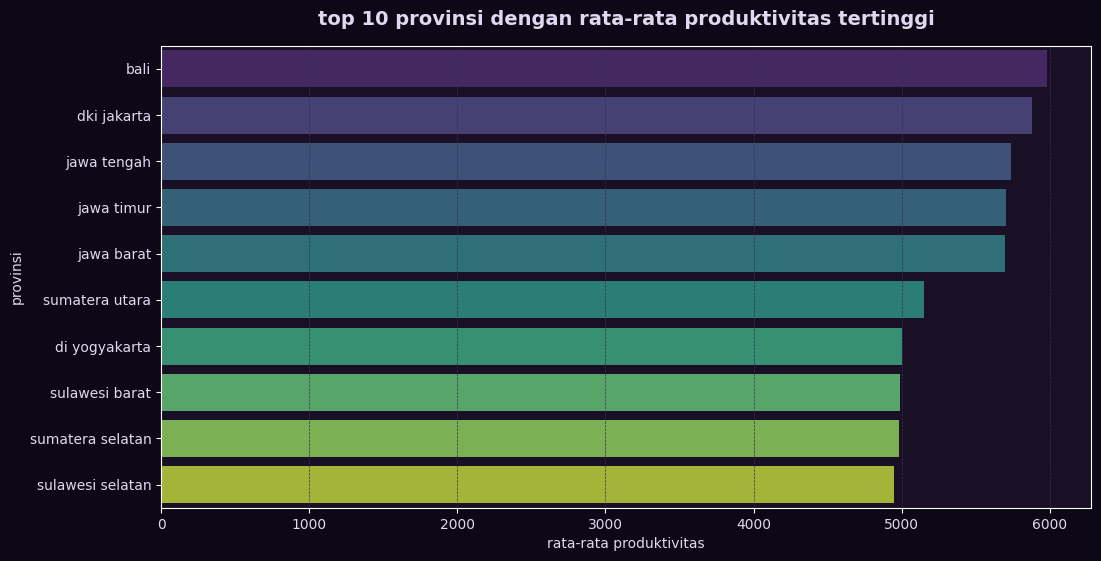

In [22]:
#bar chart
plt.figure(figsize=(12, 6))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

top_10 = df.groupby('province')['productivity'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_10.values, y=top_10.index, palette='viridis', alpha=0.9)

plt.title('top 10 provinsi dengan rata-rata produktivitas tertinggi', color=teks_color, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('rata-rata produktivitas', color=teks_color)
plt.ylabel('provinsi', color=teks_color)
plt.xticks(color=teks_color)
plt.yticks(color=teks_color)
ax.grid(color='#3b2a59', linestyle='--', linewidth=0.5, axis='x')
plt.show()

# 04. Model Building & Training

In [24]:
!pip install scikit-learn xgboost lightgbm joblib

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.5 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ ---------

In [25]:
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

In [26]:
#dki jakarta berada di urutan kedua yang mungkin terjadi karena harvested_area dari jakarta lebih kecil sehingga hasil baginya bisa sangat tinggi
df_model = df_features[df_features['province'] != 'dki jakarta'].copy()

In [41]:
#making sure isi datanya hanya numerik
kolom_non_fitur = ['province', 'date', 'year', 'region', 'rainfall_category', 'productivity', 'production', 'harvest_area', 'rainfall_per_area']
X = df_model.drop(columns=[col for col in kolom_non_fitur if col in df_model.columns])
y = df_model['productivity']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"jumlah data training: {X_train.shape[0]}")
print(f"jumlah data testing: {X_test.shape[0]}")

jumlah data training: 72
jumlah data testing: 18


berdasarkan hasil heatmap yang telah dibuat sebelumnya terlihat terdapat multikolinearitas dan juga kemungkinan hubungan non-linear sehingga model berbasis tree lebih tepat untuk ini karena mereka dapat menangkap pola non-linear dan tidak perduli dengan multikolinearitas 

In [43]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()), 
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()), 
        ('model', Ridge(random_state=42))
    ]),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBRegressor(random_state=42, objective='reg:squarederror'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

In [44]:
cv_results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    #r squared (r2) untuk evaluasi awal
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    cv_results[name] = scores
    print(f"{name.ljust(20)}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Linear Regression   : 0.6087 (+/- 0.1543)
Ridge Regression    : 0.6205 (+/- 0.1460)
Random Forest       : 0.5299 (+/- 0.2359)
XGBoost             : 0.4078 (+/- 0.3074)
LightGBM            : 0.1306 (+/- 0.3367)


In [45]:
os.makedirs('models', exist_ok=True)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    filename = name.lower().replace(' ', '_') + '.pkl'
    filepath = os.path.join('models', filename)
    
    joblib.dump(model, filepath)

print("don model training")

don model training


# 05. Model Evaluation & Comparison

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
eval_results = {}

for name, model in models.items():

    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    eval_results[name] = {
        'MAE': mae, 
        'RMSE': rmse, 
        'R² Score': r2, 
        'MAPE (%)': mape
    }

df_eval = pd.DataFrame(eval_results).T
df_eval = df_eval.sort_values(by='R² Score', ascending=False)

,MAE,RMSE,R² Score,MAPE (%)
Random Forest,401.930556,486.723444,0.728033,9.358961
XGBoost,430.586945,508.930281,0.702650,10.376858
Ridge Regression,438.702745,519.384240,0.690309,10.571025
Linear Regression,440.472626,519.772226,0.689846,10.592528
LightGBM,623.118945,719.819030,0.405163,14.751764


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24848\1982147070.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_eval['R² Score'], y=df_eval.index, palette='magma', alpha=0.9)


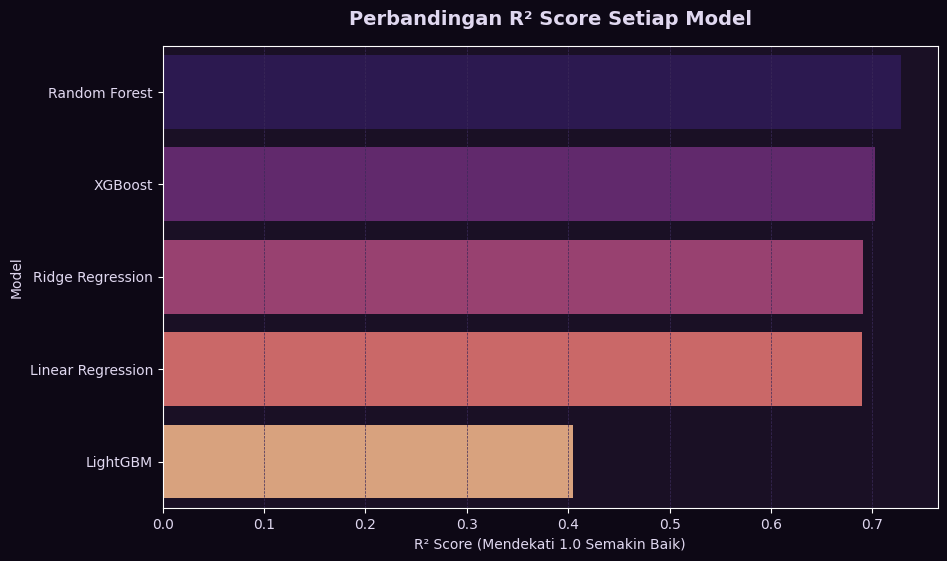

In [ ]:
display(df_eval)

os.makedirs('reports', exist_ok=True)
df_eval.to_csv('reports/model_comparison.csv')

plt.figure(figsize=(10, 6))
fig = plt.gcf()
fig.patch.set_facecolor('#0d0815')
ax = plt.gca()
ax.set_facecolor('#1a1025')

sns.barplot(x=df_eval['R² Score'], y=df_eval.index, palette='magma', alpha=0.9)

plt.title('Perbandingan R² Score Setiap Model', color='#e0d8f0', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('R² Score (Mendekati 1.0 Semakin Baik)', color='#e0d8f0')
plt.ylabel('Model', color='#e0d8f0')
plt.xticks(color='#e0d8f0')
plt.yticks(color='#e0d8f0')
ax.grid(color='#3b2a59', linestyle='--', linewidth=0.5, axis='x')

In [49]:
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/model_comparison_r2.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

<Figure size 640x480 with 0 Axes>

# 06. Model Interpretation

In [36]:
!pip install shap

   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   -- ------------------------------------- 2.6/39.2 MB 13.2 MB/s eta 0:00:03
   ----- ---------------------------------- 5.8/39.2 MB 15.0 MB/s eta 0:00:03
   ------- -------------------------------- 7.6/39.2 MB 12.4 MB/s eta 0:00:03
   --------- ------------------------------ 9.4/39.2 MB 10.9 MB/s eta 0:00:03
   ---------- ----------------------------- 10.7/39.2 MB 9.9 MB/s eta 0:00:03
   ------------ --------------------------- 12.1/39.2 MB 9.2 MB/s eta 0:00:03
   -------------- ------------------------- 13.9/39.2 MB 9.2 MB/s eta 0:00:03
   --------------- ------------------------ 15.2/39.2 MB 9.0 MB/s eta 0:00:03
   ----------------- ---------------------- 17.0/39.2 MB 8.9 MB/s eta 0:00:03
   ------------------- -------------------- 18.6/39.2 MB 8.8 MB/s eta 0:00:03
   -------------------- ------------------- 20.2/39.2 MB 8.7 MB/s eta 0:00:03
   ---------------------- ----------------- 21.8/39.2 MB 8.6 MB/s eta 0:

In [37]:
import shap

c:\Users\ASUS\Downloads\code\prediksi-kondisi-cuaca-optimal-untuk-bertanam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
best_model = models['Random Forest']

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.style.use('dark_background')
fig_color = '#0d0815'  
ax_color = '#1a1025'   
teks_color = '#e0d8f0' 

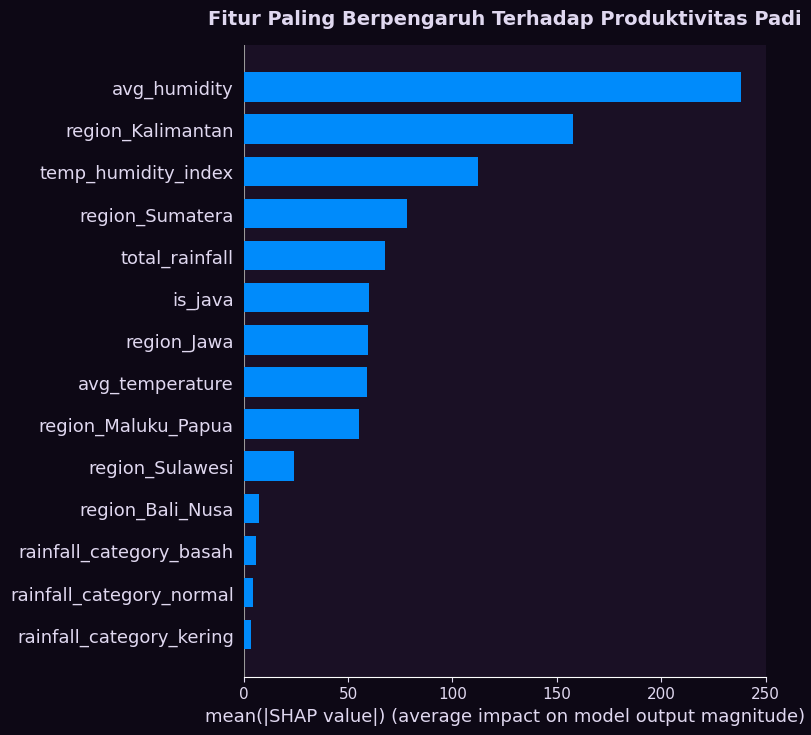

In [52]:
plt.figure(figsize=(10, 6))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)
ax = plt.gca()
ax.set_facecolor(ax_color)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Fitur Paling Berpengaruh Terhadap Produktivitas Padi', color=teks_color, fontsize=14, fontweight='bold', pad=15)
plt.xticks(color=teks_color)
plt.yticks(color=teks_color)
ax.tick_params(axis='x', colors=teks_color)
ax.tick_params(axis='y', colors=teks_color)
ax.xaxis.label.set_color(teks_color)
ax.yaxis.label.set_color(teks_color)

plt.savefig('reports/figures/shap_feature_importance.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

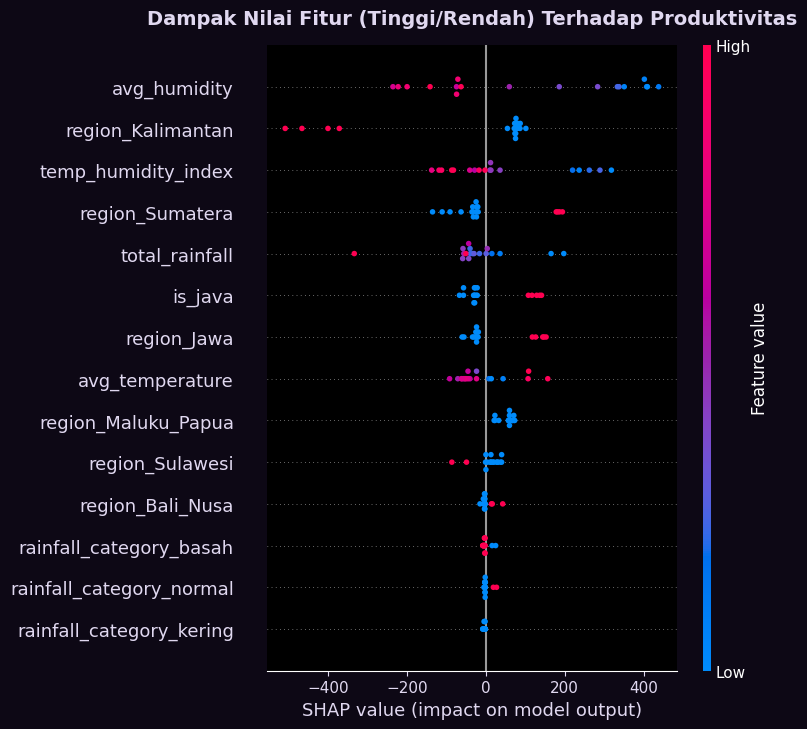

In [53]:
plt.figure(figsize=(10, 6))
fig = plt.gcf()
fig.patch.set_facecolor(fig_color)

shap.summary_plot(shap_values, X_test, show=False)
plt.title('Dampak Nilai Fitur (Tinggi/Rendah) Terhadap Produktivitas', color=teks_color, fontsize=14, fontweight='bold', pad=15)
ax = plt.gca()
ax.tick_params(axis='x', colors=teks_color)
ax.tick_params(axis='y', colors=teks_color)
ax.xaxis.label.set_color(teks_color)

plt.savefig('reports/figures/shap_summary_plot.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

sebelumnya kita menggunakan rumus productivity berikut

$Productivity = \frac{Production}{Harvest\_Area}$

tetapi berdasarkan shap value diatas model tidak belajar memprediksi produktivitas dari iklim tapi sekedar berhitung. oleh karena itu pada tahap training perlu diatur ulang dengan menghilangkan production, harvest_area, dan rainfall_per_area